In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
from astropy.table import Table
from astropy.io import fits
import seaborn as sns
from matplotlib.animation import PillowWriter
import matplotlib as mpl
from matplotlib.ticker import FormatStrFormatter
from matplotlib.colors import TwoSlopeNorm
import matplotlib.colors as mcolors
import random
import matplotlib.cm as cm
import matplotlib.lines as mlines

params = {
   'axes.labelsize': 20,
   'font.size': 15,
   'legend.fontsize': 14,
   'xtick.minor.visible': True,
   'ytick.minor.visible': True,
   'xtick.labelsize': 15,
   'ytick.labelsize': 15,
   'text.usetex': True, #to use TeX in your labels
   'font.family':'serif',
   'axes.titlesize': 20,
   'xtick.direction': 'in',
   'ytick.direction': 'in',
   'xtick.top': True,
   'ytick.right': True,
   'xtick.major.size': 6,
   'xtick.minor.size': 3,
   'ytick.major.size': 6,
   'ytick.minor.size': 3
   }
rcParams.update(params)

import pandas as pd
from astropy.io import fits
from astropy.table import Table

def decode(df):
    """
    Decode DataFrame with byte strings into ordinary strings.
    """
    str_df = df.select_dtypes([object])
    str_df = str_df.stack().str.decode('utf-8').unstack()
    for col in str_df:
        df[col] = str_df[col]
    return df

def fitsrec_to_pandas(fits_rec):
    """
    Convert a FITS_rec object (from astropy.io.fits) to a pandas DataFrame.
    """
    # Convert FITS_rec to astropy Table first
    table = Table(fits_rec)
    
    # Filter out multidimensional columns
    cols = [name for name in table.colnames if len(table[name].shape) <= 1]
    
    # Convert to pandas DataFrame
    df = table[cols].to_pandas()
    
    # Decode byte strings
    df = decode(df)
    
    return df

In [27]:
with fits.open('../../data/astroNN_2proc_crossmatch.fits') as hdul:
    astronn_data = hdul[1].data
    twoprocess_data = hdul[2].data

two_process_data = fitsrec_to_pandas(twoprocess_data)
data_astronn = fitsrec_to_pandas(astronn_data)

# Identify columns that are NOT already in two_process_data
#new_cols = data_astronn.columns.difference(two_process_data.columns)
new_cols = ['galr', 'galz']

# Concatenate, keeping two_process_data's versions of duplicate columns
data = pd.concat(
    [
        two_process_data.reset_index(drop=True),
        data_astronn[new_cols].reset_index(drop=True)
    ],
    axis=1
)

data = data[data['DFLAG'] == 0]

data['MG_H'] = data['MG_H_ASPCAP_ADJ']
data['FE_H'] = data['FE_H_ASPCAP_ADJ']
data['MN_H'] = data['MN_H_ASPCAP_ADJ']
data['NI_H'] = data['NI_H_ASPCAP_ADJ']
data['AL_H'] = data['AL_H_ASPCAP_ADJ']

data['MN_O'] = data['MN_H_ASPCAP_ADJ'] - data['O_H_ASPCAP_ADJ']
data['FE_O'] = data['FE_H_ASPCAP_ADJ'] - data['O_H_ASPCAP_ADJ']
data['MN_MG'] = data['MN_H_ASPCAP_ADJ'] - data['MG_H_ASPCAP_ADJ']
data['FE_MG'] = data['FE_H_ASPCAP_ADJ'] - data['MG_H_ASPCAP_ADJ']
data['MG_FE'] = data['MG_H_ASPCAP_ADJ'] - data['FE_H_ASPCAP_ADJ']
data['MN_FE'] = data['MN_H_ASPCAP_ADJ'] - data['FE_H_ASPCAP_ADJ']
data['NI_MG'] = data['NI_H_ASPCAP_ADJ'] - data['MG_H_ASPCAP_ADJ']
data['NI_FE'] = data['NI_H_ASPCAP_ADJ'] - data['FE_H_ASPCAP_ADJ']
data['AL_MG'] = data['AL_H_ASPCAP_ADJ'] - data['MG_H_ASPCAP_ADJ']
data['AL_FE'] = data['AL_H_ASPCAP_ADJ'] - data['FE_H_ASPCAP_ADJ']

data = data[(data['galz'] < 2) & (data['galz'] > -2) & (data['galr'] < 15) & (data['galr'] > 3)]

pos_FE_H = data[(data['FE_H'] > 0)]
neg_FE_H = data[(data['FE_H'] < 0)]
data_high_alpha = pd.concat([pos_FE_H[(pos_FE_H['MG_FE'] > 0.12)], neg_FE_H[neg_FE_H['MG_FE'] > 0.12 - 0.13 * neg_FE_H['FE_H']]])
data_low_alpha = pd.concat([pos_FE_H[(pos_FE_H['MG_FE'] < 0.12)], neg_FE_H[neg_FE_H['MG_FE'] < 0.12 - 0.13 * neg_FE_H['FE_H']]])


data_high_alpha['high_low_alpha'] = "high"
data_low_alpha['high_low_alpha'] = "low"
data_high_alpha['color'] = "hotpink"
data_low_alpha['color'] = "cornflowerblue"

data = pd.concat([data_high_alpha, data_low_alpha], ignore_index=True)

#data = data[data['LOGG'] > 1.4]

# 1. Making the galaxies

In [28]:
from chemevo import evolution_V1 as evo

mg_h_big_bin_edges = np.arange(-0.7, 0.50, 0.20) 
mg_h_big_bin_centers = 0.5 * (mg_h_big_bin_edges[:-1] + mg_h_big_bin_edges[1:])

data['MG_H_big_bin'] = pd.cut(data['MG_H'], bins = mg_h_big_bin_edges, right=False, labels=False)
    
t_array = np.linspace(0.0001,14,int(1e3))
t_array_trunc = np.linspace(0.0001,6,int(1e3))
dt = t_array[1] - t_array[0]

In [29]:
gcc_Mn_def = 0.40
gcc_ratio_def = 2
alpha_cc_def = 0.60
alpha_ia_def = 0.30

In [30]:
# SFRs

def rise_fall(t, tau_1, tau_2):
    return 1 * (1 - np.exp(-t/tau_1)) * np.exp(-t/tau_2)

m_g_array_const = np.ones(len(t_array))
tau_sfh = 6 #Gyrs
m_g_array_exp = 1 * np.exp(-t_array/tau_sfh)
m_g_array_exp /= np.trapezoid(m_g_array_exp, t_array)

m_g_array_rise_fall_1 = rise_fall(t_array, 2, 8)
m_g_array_rise_fall_1 /= np.trapezoid(m_g_array_rise_fall_1, t_array)

m_g_array_rise_fall_2 = rise_fall(t_array, 4, 30)
m_g_array_rise_fall_2 /= np.trapezoid(m_g_array_rise_fall_2, t_array)

m_g_array_rise_fall_3 = rise_fall(t_array, 6, 12)
m_g_array_rise_fall_3 /= np.trapezoid(m_g_array_rise_fall_3, t_array)

#sfrs = [m_g_array_const, m_g_array_exp, m_g_array_rise_fall_1, m_g_array_rise_fall_2, m_g_array_rise_fall_3]
sfrs = [m_g_array_rise_fall_1]

In [31]:
#etas = np.logspace(-2, 1, 10)
#tau_stars = np.linspace(0.5, 6, 10)

etas = [1e-10, 1]
tau_stars = [2, 3]

gals_list_all = []

n_gals = len(etas) * len(tau_stars) * len(sfrs)
print("n_gals = ", n_gals)

n_gals =  4


In [32]:
for i_eta in range(len(etas)):
    for i_taustar in range(len(tau_stars)):
        for i_sfrs in range(len(sfrs)):
            eta = etas[i_eta]
            tau_star = tau_stars[i_taustar]
            sfr = sfrs[i_sfrs]

            gals_list_all.append(evo.Galaxy(t_array=t_array, m_g_array=sfr, tau_star=tau_star,
                                     eta=eta, Upsilon=1, 
                                     yields_ref="W2024,moreFe",
                                     g_cc_Mn=gcc_Mn_def, g_ratio_Mn=gcc_ratio_def,
                                     alpha_cc_Mn=alpha_cc_def, alpha_Ia_Mn=alpha_ia_def))
            
len(gals_list_all)

4

In [33]:
random.seed(42)
random_gals_list = random.sample(gals_list_all, 4)

In [34]:
random_gals_list[1].tau_star_arr[0]

np.float64(3.0)

In [35]:
random_gals_list[3].eta_arr[0]

np.float64(1.0)

# 2. Find line crossing the data

In [36]:
from scipy.stats import linregress

n_bins = 5

slopes_mn_fe, intercepts_mn_fe = np.zeros(n_bins), np.zeros(n_bins)
slopes_mn_mg, intercepts_mn_mg = np.zeros(n_bins), np.zeros(n_bins)

for i in range(n_bins):
    subset = data[data['MG_H_big_bin'] == i]
    x = subset['FE_MG']
    
    # Loop through both y-variables to save space
    for y_col, slopes, intercepts in [
        ('MN_FE', slopes_mn_fe, intercepts_mn_fe), 
        ('MN_MG', slopes_mn_mg, intercepts_mn_mg)
    ]:
        y = subset[y_col]
        mask = np.isfinite(x) & np.isfinite(y)
        
        if mask.sum() > 2:
            slope, intercept, *_ = linregress(x[mask], y[mask])
            slopes[i] = slope
            intercepts[i] = intercept

# 3. Plotting functions

In [37]:
def downsample(df, N):
    if len(df) > N:
        return df.sample(N, random_state=42)   # random subset of N
    else:
        return df
    
def find_endpoints(galaxies, bin_centers):
    endpoints_gals = []
    for bin_cent in bin_centers:
        endpoints = []
        for gal in galaxies:
            mg_h = gal.Mg_H
            crossed = False
            for indx in range(len(mg_h)):
                mg_h_at_time = mg_h[indx]
                if mg_h_at_time > bin_cent:
                    endpoints.append(indx)
                    crossed = True
                    break
            if not crossed:
                endpoints.append(-1) # Critical fix to maintain 1:1 mapping with galaxies
        endpoints_gals.append(np.array(endpoints))
    return endpoints_gals

fe_mg_bin_edges = np.arange(-0.35, 0.15, 0.1)
fe_mg_bin_centers = 0.5 * (fe_mg_bin_edges[:-1] + fe_mg_bin_edges[1:])

def compute_ratios(gals_list, endpoints, element='Fe'):
    """Calculates arrays and the max plot value for a specific element ratio."""
    all_ratios, scatter_maxes = [], []
    for k, gal in enumerate(gals_list):
        if element == 'Fe':
            ratio = gal.compute_z_Fe_Ia() / gal.compute_z_Fe_CC()
        elif element == 'X':
            ratio = gal.compute_z_X_Ia() / gal.compute_z_X_CC()
        
        all_ratios.append(ratio)
        for i in range(len(endpoints)):
            if endpoints[i][k] != -1:
                scatter_maxes.append(ratio[endpoints[i][k]])
                
    return all_ratios, (max(scatter_maxes) if scatter_maxes else 1)

# A) Spaghetti plots

/var/folders/g0/fl404sj151l2v9xcdkjz9fq80000gn/T/ipykernel_54079/3374549026.py:35: RuntimeWarning: invalid value encountered in divide
  ratio = gal.compute_z_X_Ia() / gal.compute_z_X_CC()


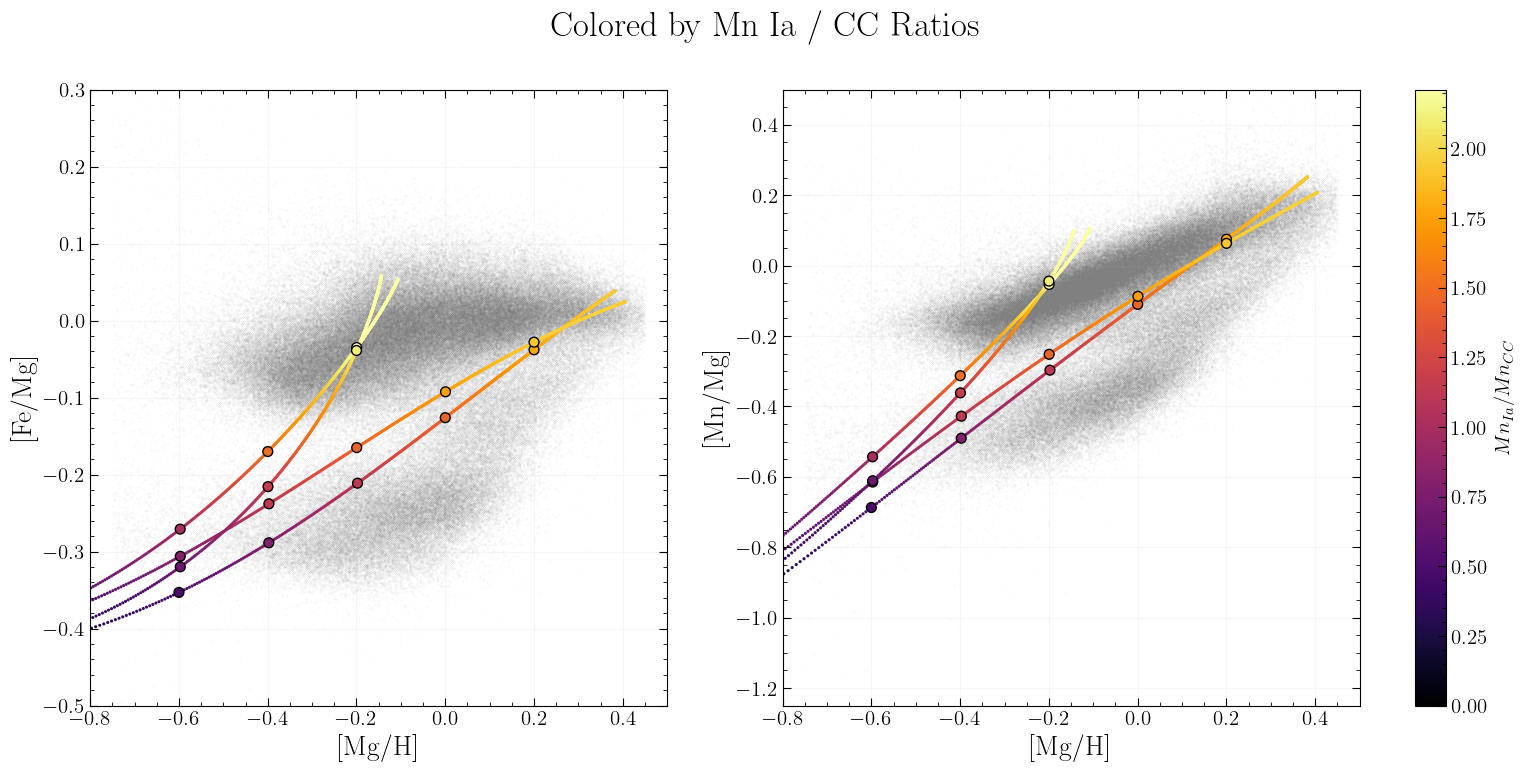

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import numpy as np

# 1. Pre-calculate endpoints and ratios
gals_endpoints = find_endpoints(random_gals_list, mg_h_big_bin_centers)

# Compute ONLY Mn ratios (assuming X='Mn')
mn_ratios, mn_max = compute_ratios(random_gals_list, gals_endpoints, element='X') 

# Setup Colormap and Normalizations based on the ratio ranges
cmap = plt.get_cmap('inferno')
mn_norm = mcolors.Normalize(vmin=0, vmax=mn_max)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18,8))

# --- Panel 1: [Fe/Mg] ---
ax1.scatter(data['MG_H'], data['FE_MG'], s=0.01, color='gray', alpha=0.3)

for k, gal in enumerate(random_gals_list):
    ratio_arr = np.array(mn_ratios[k])
    
    # Plot continuous track colored by Mn ratio
    ax1.scatter(gal.Mg_H, gal.Fe_Mg, c=ratio_arr, cmap=cmap, norm=mn_norm, s=5, edgecolor='none')
    
    # Extract valid endpoints
    valid_idxs = [gals_endpoints[b][k] for b in range(len(mg_h_big_bin_centers)) if gals_endpoints[b][k] != -1]
    
    if valid_idxs:
        ax1.scatter(gal.Mg_H[valid_idxs], gal.Fe_Mg[valid_idxs], c=ratio_arr[valid_idxs], 
                    s=50, zorder=10, marker='o', edgecolors='black', cmap=cmap, norm=mn_norm)

ax1.set_xlim(-0.8, 0.5)
ax1.set_ylim(-0.5, 0.3)
ax1.set_xlabel('[Mg/H]')
ax1.set_ylabel('[Fe/Mg]')
ax1.grid(True, alpha=0.1)

# --- Panel 2: [Mn/Mg] ---
ax2.scatter(data['MG_H'], data['MN_MG'], s=0.01, color='gray', alpha=0.3)

for k, gal in enumerate(random_gals_list):
    ratio_arr = np.array(mn_ratios[k])
    
    # Plot continuous track colored by Mn ratio
    ax2.scatter(gal.Mg_H, gal.Mn_Mg, c=ratio_arr, cmap=cmap, norm=mn_norm, s=5, edgecolor='none')
    
    valid_idxs = [gals_endpoints[b][k] for b in range(len(mg_h_big_bin_centers)) if gals_endpoints[b][k] != -1]
    
    if valid_idxs:
        ax2.scatter(gal.Mg_H[valid_idxs], gal.Mn_Mg[valid_idxs], c=ratio_arr[valid_idxs], 
                    s=50, zorder=10, marker='o', edgecolors='black', cmap=cmap, norm=mn_norm)

ax2.set_xlim(-0.8, 0.5)
ax2.set_ylim(-1.25, 0.5)
ax2.set_xlabel('[Mg/H]')

ax2.set_ylabel('[Mn/Mg]')
ax2.grid(True, alpha=0.1)

# Add a single shared Mn colorbar
sm_mn = cm.ScalarMappable(cmap=cmap, norm=mn_norm)
sm_mn.set_array([]) 
cbar = fig.colorbar(sm_mn, ax=[ax1, ax2], fraction=0.05, pad=0.04)
cbar.set_label(r'$Mn_{Ia} / Mn_{CC} $', fontsize=15)

plt.suptitle("Colored by Mn Ia / CC Ratios", fontsize=25)
plt.show()

# B) [Mn/Fe] vs [Fe/Mg] plots

/var/folders/g0/fl404sj151l2v9xcdkjz9fq80000gn/T/ipykernel_54079/3374549026.py:35: RuntimeWarning: invalid value encountered in divide
  ratio = gal.compute_z_X_Ia() / gal.compute_z_X_CC()


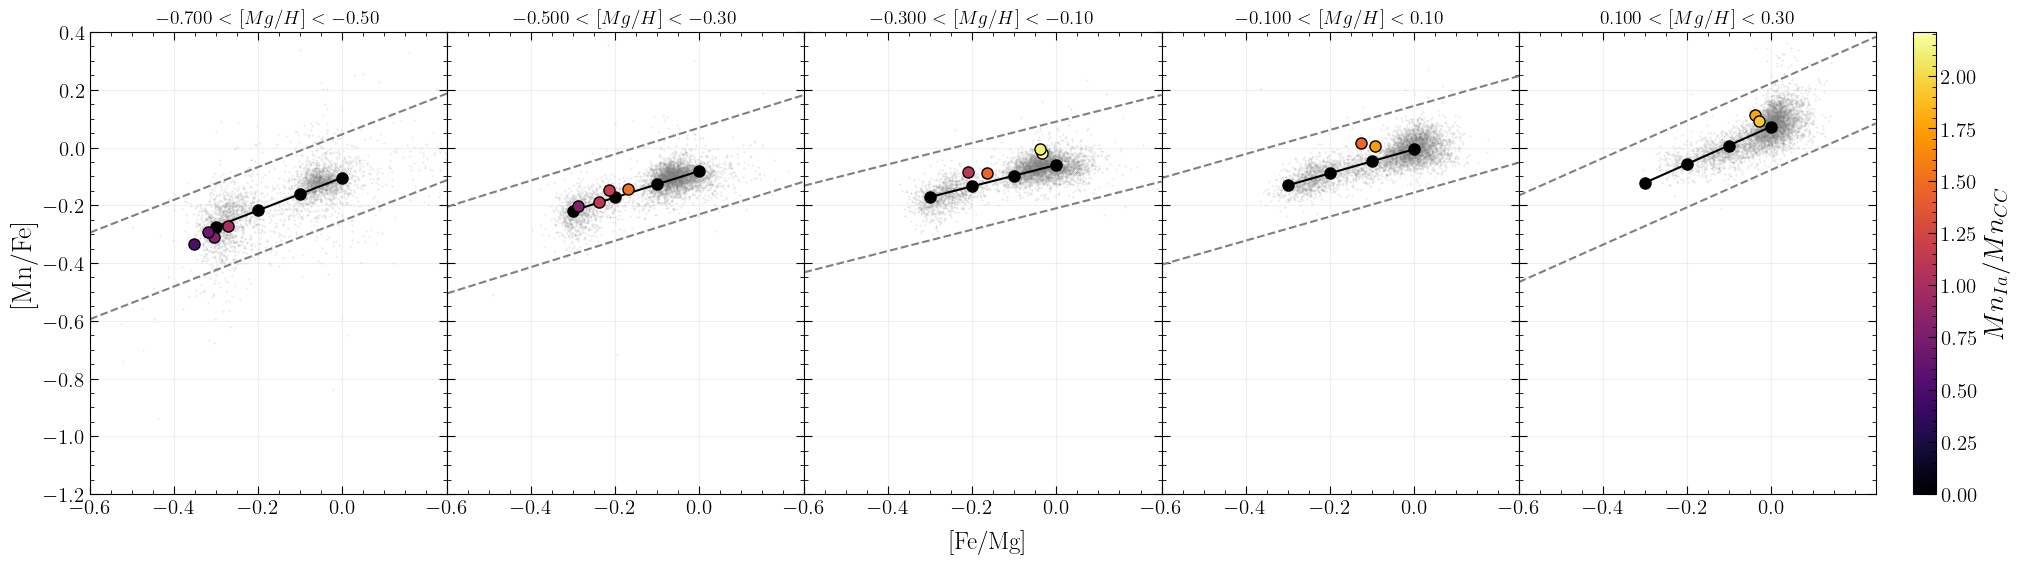

In [41]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import numpy as np

# --- Set figure dimensions directly ---
fig_x = 24
fig_y = 6
gals_list = random_gals_list

# --- 1. Pre-calculate endpoints and ratios FIRST ---
gals_endpoints = find_endpoints(gals_list, mg_h_big_bin_centers)
mn_ratios, mn_max = compute_ratios(gals_list, gals_endpoints, element='X') 

# --- 2. Setup Colormap based on the ratio range ---
norm = mcolors.Normalize(vmin=0, vmax=mn_max)
cmap = plt.get_cmap('inferno')

fig, axes = plt.subplots(1, 5, figsize=(fig_x, fig_y), sharex=True, sharey=True)
axes = axes.flatten()

for i, ax in enumerate(axes):
    # Plot background data
    downsampled_data = downsample(data[data['MG_H_big_bin'] == i], 5000)
    ax.scatter(downsampled_data['FE_MG'], downsampled_data['MN_FE'], s=0.1, color='gray', alpha=0.3)

    # Plot median line
    y_centers = slopes_mn_fe[i] * fe_mg_bin_centers + intercepts_mn_fe[i]
    y_lower = slopes_mn_fe[i] * np.linspace(-0.6, 0.25, 100) + intercepts_mn_fe[i] - 0.15
    y_upper = slopes_mn_fe[i] * np.linspace(-0.6, 0.25, 100) + intercepts_mn_fe[i] + 0.15
    ax.plot(fe_mg_bin_centers, y_centers, '-o', color='black', ms=8, zorder=10)

    # Plot parallel lines +/- 0.1 dex
    ax.plot(np.linspace(-0.6, 0.25, 100), y_lower, color='gray', linestyle='--')
    ax.plot(np.linspace(-0.6, 0.25, 100), y_upper, color='gray', linestyle='--')

    # idxs contains the stopping index for EACH galaxy in gals_list for this bin 'i'
    idxs = gals_endpoints[i]

    for k, (gal, idx) in enumerate(zip(gals_list, idxs)):
        if idx != -1:  # Ensure the galaxy actually crossed this bin center
            fe_mg = gal.Fe_Mg[idx]
            mn_fe = gal.Mn_Fe[idx]
            
            eta = gal.eta_arr[0]
            taustar = gal.tau_star_arr[0]
            
            # --- 3. Extract dynamic color from ratio array ---
            ratio_val = mn_ratios[k][idx]
            current_color = cmap(norm(ratio_val))
            
            sfr = gal.m_g_array
            if np.array_equal(sfr, m_g_array_const):
                sfr_label = "const SFR"
            elif np.array_equal(sfr, m_g_array_exp):
                sfr_label = "exp SFR"
            elif np.array_equal(sfr, m_g_array_rise_fall_1):
                sfr_label = "rise+fall  1"
            elif np.array_equal(sfr, m_g_array_rise_fall_2):
                sfr_label = "rise+fall  2"
            elif np.array_equal(sfr, m_g_array_rise_fall_3):
                sfr_label = "rise+fall  3"
            else:
                sfr_label = "unknown SFR"

            ax.plot(fe_mg, mn_fe, marker='o', color=current_color, linewidth=0,
                    markeredgecolor='black', markersize=8, zorder=11,
                    label=rf"$\eta = {eta:.2f}, \ \tau_* = {taustar}$, {sfr_label}")

    if i == 0:
        ax.set_ylabel('[Mn/Fe]')
    
    ax.set_title(
        rf'${mg_h_big_bin_edges[i]:.3f} < [Mg/H] < {mg_h_big_bin_edges[i+1]:.2f}$',
        fontsize=14
    )
    ax.set_xticks(np.arange(-0.6, 0.2, 0.2))
    ax.grid(True, alpha=0.2)
    ax.set_xlim(-0.60, 0.25)
    ax.set_ylim(-1.2, 0.40)

fig.supxlabel('[Fe/Mg]')
fig.subplots_adjust(wspace=0)

# Add the colorbar using ScalarMappable
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([]) 
cbar = fig.colorbar(sm, ax=axes, fraction=0.02, pad=0.02)
cbar.set_label(r'$Mn_{Ia} / Mn_{CC} $', fontsize=20) # Updated label

plt.show()

# B) [Mn/Mg] vs [Fe/Mg] plots

/var/folders/g0/fl404sj151l2v9xcdkjz9fq80000gn/T/ipykernel_54079/3374549026.py:35: RuntimeWarning: invalid value encountered in divide
  ratio = gal.compute_z_X_Ia() / gal.compute_z_X_CC()


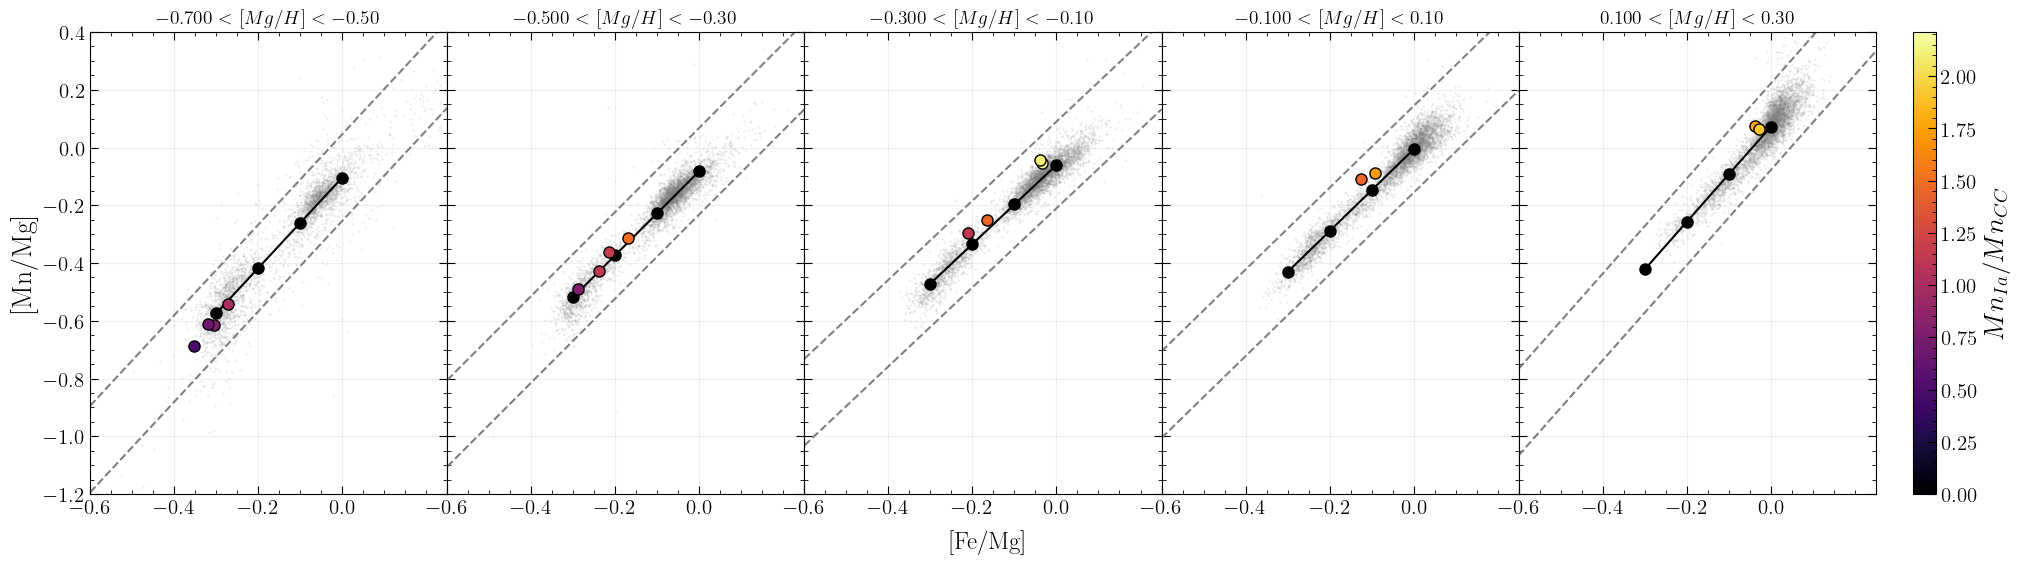

In [49]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import numpy as np

# --- Set figure dimensions directly ---
fig_x = 24
fig_y = 6
gals_list = random_gals_list

# --- 1. Pre-calculate endpoints and ratios FIRST ---
gals_endpoints = find_endpoints(gals_list, mg_h_big_bin_centers)
mn_ratios, mn_max = compute_ratios(gals_list, gals_endpoints, element='X') 

# --- 2. Setup Colormap based on the ratio range ---
norm = mcolors.Normalize(vmin=0, vmax=mn_max)
cmap = plt.get_cmap('inferno')

fig, axes = plt.subplots(1, 5, figsize=(fig_x, fig_y), sharex=True, sharey=True)
axes = axes.flatten()

for i, ax in enumerate(axes):
    # Plot background data
    downsampled_data = downsample(data[data['MG_H_big_bin'] == i], 5000)
    ax.scatter(downsampled_data['FE_MG'], downsampled_data['MN_MG'], s=0.1, color='gray', alpha=0.3)

    # Plot median line
    y_centers = slopes_mn_mg[i] * fe_mg_bin_centers + intercepts_mn_mg[i]
    y_lower = slopes_mn_mg[i] * np.linspace(-0.6, 0.25, 100) + intercepts_mn_mg[i] - 0.15
    y_upper = slopes_mn_mg[i] * np.linspace(-0.6, 0.25, 100) + intercepts_mn_mg[i] + 0.15
    ax.plot(fe_mg_bin_centers, y_centers, '-o', color='black', ms=8, zorder=10)

    # --- Plot parallel lines +/- 0.1 dex ---
    ax.plot(np.linspace(-0.6, 0.25, 100), y_lower, color = 'gray', linestyle = '--')
    ax.plot(np.linspace(-0.6, 0.25, 100), y_upper, color = 'gray', linestyle = '--')

    # idxs contains the stopping index for EACH galaxy in gals_list for this bin 'i'
    idxs = gals_endpoints[i]

    for k, (gal, idx) in enumerate(zip(gals_list, idxs)):
        if idx != -1:  # Ensure the galaxy actually crossed this bin center
            fe_mg = gal.Fe_Mg[idx]
            mn_mg = gal.Mn_Mg[idx]
            
            eta = gal.eta_arr[0]
            taustar = gal.tau_star_arr[0]
            
            # --- 3. Extract dynamic color from ratio array ---
            ratio_val = mn_ratios[k][idx]
            current_color = cmap(norm(ratio_val))
            
            sfr = gal.m_g_array
            if np.array_equal(sfr, m_g_array_const):
                sfr_label = "const SFR"
            elif np.array_equal(sfr, m_g_array_exp):
                sfr_label = "exp SFR"
            elif np.array_equal(sfr, m_g_array_rise_fall_1):
                sfr_label = "rise+fall  1"
            elif np.array_equal(sfr, m_g_array_rise_fall_2):
                sfr_label = "rise+fall  2"
            elif np.array_equal(sfr, m_g_array_rise_fall_3):
                sfr_label = "rise+fall  3"
            else:
                sfr_label = "unknown SFR"

            ax.plot(fe_mg, mn_mg, marker='o', color=current_color, linewidth=0,
                    markeredgecolor='black', markersize=8, zorder=11,
                    label = rf"$\eta = {eta:.2f}, \ \tau_* = {taustar}$, {sfr_label}")

    if i == 0:
        ax.set_ylabel('[Mn/Mg]')
    
    ax.set_title(
        rf'${mg_h_big_bin_edges[i]:.3f} < [Mg/H] < {mg_h_big_bin_edges[i+1]:.2f}$',
        fontsize=14
    )
    ax.set_xticks(np.arange(-0.6, 0.2, 0.2))
    ax.grid(True, alpha=0.2)
    ax.set_xlim(-0.60, 0.25)
    ax.set_ylim(-1.2, 0.40)

fig.supxlabel('[Fe/Mg]')
fig.subplots_adjust(wspace=0)

# Add the colorbar using ScalarMappable
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([]) 
cbar = fig.colorbar(sm, ax=axes, fraction=0.02, pad=0.02)
cbar.set_label('$Mn_{Ia} / Mn_{CC} $', fontsize=20) # Updated label

plt.show()